In [20]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from sklearn.datasets import load_digits
import re
import json
import pickle
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as CFeature
import random
from scipy.stats import bootstrap
import pacmap

## Start in code cell 7 if CombinedDataset.nc is already created.


Some Additional Filtering that wasn't included in the original data consolidation workflow

In [ ]:
# The path for HAFS consolidated Date
folder_path = 'Model_Data/CompleteData'

# HAFS Data is in multiple NC files. Consolidate_Data creates one dataset
ds = utils.consolidate_data(folder_path)

# Checking for NA's
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')



Function to get frame intensity change. Lead time is customizable but defaults to 24 hours in the future.

In [ ]:
# results = get_future_intensity(ds_cleaned.isel(levels = 0)['frame_link'].values)

ds_cleaned['24HrMaxWinds'] = (('frame_number'), np.squeeze(results['24hr Max Winds']))
ds_cleaned['24HrMinimumCentralPressure'] = (('frame_number'), np.squeeze(results['24hr Minimum Central Pressure']))

# Limiting frames to tropical storm strength or stronger (17 m/s or stronger)
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] >= 17, drop = True)

# Only using storms in the Northern Hemisphere
ds_cleaned = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')

ds_cleaned.to_netcdf('CombinedDataset.nc')

# with open('intensity_change.pkl', 'rb') as file:
#     dict = pickle.load(file)

In [ ]:
data_path = 'Model_Data/CompleteData/withRI'
directory_path = Path(data_path)
files_only = [data_path + '/' + entry.name for entry in directory_path.iterdir() if entry.is_file() and entry.name != '.gitkeep']
ds_cleaned = xr.open_mfdataset(files_only, concat_dim = 'frame_number', combine = 'nested')

In [ ]:
ds_cleaned = ds_cleaned.compute()
ds_cleaned = ds_cleaned.dropna(dim = 'frame_number', how = 'any')
ds_cleaned = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] > 17, drop = True)



** Start Here if CombinedDataset.nc is already created. **

In [ ]:
ds_cleaned = xr.open_dataset('CombinedDataset.nc')

In [ ]:
lats = ds_cleaned['center_lat'].isel(levels = 0).values
lons = ds_cleaned['center_lon'].isel(levels = 0).values


fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,8), subplot_kw = {'projection': ccrs.PlateCarree()})

ax.scatter(lons, lats, transform = ccrs.PlateCarree(), s = 3)
ax.add_feature(CFeature.COASTLINE)
ax.set_title('Storm Locations')

In [ ]:
# Creating the values to grade against. (Minimum Central Pressure, Maximum Surface Wind, 24hr Pressure change,
#                                        24hr Wind Change, and Radius of Maximum Winds)

mslp = ds_cleaned['center_pressure'].values[:,0]
max_winds = ds_cleaned['max_wind'].values[:,0]
pressure_change = ds_cleaned['24HrMinimumCentralPressure'].isel(levels = 0).values - mslp
wind_change = ds_cleaned['24HrMaxWinds'].isel(levels = 0).values - max_winds


wind_change_min = np.min(wind_change)
wind_change_max = np.max(wind_change)
windspeed_min = np.min(max_winds)
windspeed_max = np.max(max_winds)

# max_windspeed_radius = []
# for radius in max_windspeed_coords['radius']:
#     max_windspeed_radius.append(ds_cleaned.radius.isel(radius = radius).values.squeeze())
# max_windspeed_radius = np.squeeze(max_windspeed_radius)

# max_windspeed_radius_scaled= (max_windspeed_radius/np.max(max_windspeed_radius))*30

In [ ]:
storm_strenght_bins = [17,33,43,50,58,70, np.max(max_winds)+1]
bin_centers = [(storm_strenght_bins[i] + storm_strenght_bins[i+1]) / 2 for i in range(len(storm_strenght_bins)-1)]
bin_names = ['Tropical Storms', 'Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']

plt.hist(max_winds, bins = storm_strenght_bins, rwidth = 0.75)
plt.xticks(bin_centers, bin_names)
plt.title('Distribution of Storm Strength within the Dataset')


In [ ]:
# Normalizing data assuming gaussian distribution

# normalized_data_gh_sfc = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
# normalized_data_t_sfc = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 0))
# normalized_data_rh_sfc = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
# normalized_data_gh_700 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
# normalized_data_t_700 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 1))
# normalized_data_rh_700 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
# normalized_data_gh_200 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
# normalized_data_t_200 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 2))
# normalized_data_rh_200 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [ ]:
# plt.hist(normalized_data_rh_700.reshape(-1,1))

In [4]:
# Normalizing data while keeping underlying distribution

normalized_data_gh_sfc = utils.minmax_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
normalized_data_t_sfc = utils.minmax_data_normalizer(ds_cleaned['t'].isel(levels = 0))
normalized_data_rh_sfc = utils.minmax_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
normalized_data_gh_700 = utils.minmax_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
normalized_data_t_700 = utils.minmax_data_normalizer(ds_cleaned['t'].isel(levels = 1))
normalized_data_rh_700 = utils.minmax_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
normalized_data_gh_200 = utils.minmax_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
normalized_data_t_200 = utils.minmax_data_normalizer(ds_cleaned['t'].isel(levels = 2))
normalized_data_rh_200 = utils.minmax_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [ ]:
plt.hist(normalized_data_t_700.reshape(-1,1))

In [5]:
# Constructing 700mb level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_700 = np.stack((
                          normalized_data_gh_700, normalized_data_t_700, normalized_data_rh_700,
                          ), 
                          axis = 0).reshape(398, 3 * 720 * 501)
heights_700 = np.stack(normalized_data_gh_700,axis = 0).reshape(398, 1 * 720 * 501)
t_700 = np.stack(normalized_data_t_700,axis = 0).reshape(398, 1 * 720 * 501)
rh_700 = np.stack(normalized_data_rh_700,axis = 0).reshape(398, 1 * 720 * 501)


In [6]:
# Constructing surface level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_sfc = np.stack((
                          normalized_data_gh_sfc, normalized_data_t_sfc, normalized_data_rh_sfc,
                          ), 
                          axis = 0).reshape(398, 3 * 720 * 501)
heights_sfc = np.stack(normalized_data_gh_sfc,axis = 0).reshape(398, 1 * 720 * 501)
t_sfc = np.stack(normalized_data_t_sfc,axis = 0).reshape(398, 1 * 720 * 501)
rh_sfc = np.stack(normalized_data_rh_sfc,axis = 0).reshape(398, 1 * 720 * 501)

In [ ]:
# Constructing a composite surface/700mb level dataset. Array contains surface 
# temperature data, and surface and 700mb geopotential heights. Met values were
# selected based on best results from the individual UMAP reductions.

combined_sfc700_gph_t = np.stack((
                          normalized_data_gh_sfc, normalized_data_gh_700, normalized_data_t_sfc,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)

Creating Surface Level UMAP Reductions

In [ ]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_Fullsfc_n3 = reducer3.fit_transform(combined_sfc)
# embedding_GHsfc_n3 = reducer3.fit_transform(heights_sfc)
# embedding_Tsfc_n3 = reducer3.fit_transform(t_sfc)
# embedding_RHsfc_n3 = reducer3.fit_transform(rh_sfc)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 12, init = 'pca')
# reducer5 = pacmap.PaCMAP(n_components = 2, n_neighbors = 30, MN_ratio = 0.5, FP_ratio = 2, random_state = 12)
embedding_Fullsfc_n5 = reducer5.fit_transform(combined_sfc)
embedding_GHsfc_n5 = reducer5.fit_transform(heights_sfc)
embedding_Tsfc_n5 = reducer5.fit_transform(t_sfc)
embedding_RHsfc_n5 = reducer5.fit_transform(rh_sfc)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_Fullsfc_n15 = reducer15.fit_transform(combined_sfc)
# embedding_GHsfc_n15 = reducer15.fit_transform(heights_sfc)
# embedding_Tsfc_n15 = reducer15.fit_transform(t_sfc)
# embedding_RHsfc_n15 = reducer15.fit_transform(rh_sfc)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_Fullsfc_n10 = reducer10.fit_transform(combined_sfc)
# embedding_GHsfc_n10 = reducer10.fit_transform(heights_sfc)
# embedding_Tsfc_n10 = reducer10.fit_transform(t_sfc)
# embedding_RHsfc_n10 = reducer10.fit_transform(rh_sfc)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_Fullsfc_n20 = reducer20.fit_transform(combined_sfc)
# embedding_GHsfc_n20 = reducer20.fit_transform(heights_sfc)
# embedding_Tsfc_n20 = reducer20.fit_transform(t_sfc)
# embedding_RHsfc_n20 = reducer20.fit_transform(rh_sfc)


Creating 700mb Level UMAP Reductions

In [ ]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_Full700_n3 = reducer3.fit_transform(combined_700)
# embedding_GH700_n3 = reducer3.fit_transform(heights_700)
# embedding_T700_n3 = reducer3.fit_transform(t_700)
# embedding_RH700_n3 = reducer3.fit_transform(rh_700)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 4, random_state = 12, init = 'pca')
# reducer5 = pacmap.PaCMAP(n_components = 2, n_neighbors = 30, MN_ratio = 0.5, FP_ratio = 2, random_state = 12)
embedding_Full700_n5 = reducer5.fit_transform(combined_700)
embedding_GH700_n5 = reducer5.fit_transform(heights_700)
embedding_T700_n5 = reducer5.fit_transform(t_700)
embedding_RH700_n5 = reducer5.fit_transform(rh_700)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_Full700_n15 = reducer15.fit_transform(combined_700)
# embedding_GH700_n15 = reducer15.fit_transform(heights_700)
# embedding_T700_n15 = reducer15.fit_transform(t_700)
# embedding_RH700_n15 = reducer15.fit_transform(rh_700)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_Full700_n10 = reducer10.fit_transform(combined_700)
# embedding_GH700_n10 = reducer10.fit_transform(heights_700)
# embedding_T700_n10 = reducer10.fit_transform(t_700)
# embedding_RH700_n10 = reducer10.fit_transform(rh_700)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_Full700_n20 = reducer20.fit_transform(combined_700)
# embedding_GH700_n20 = reducer20.fit_transform(heights_700)
# embedding_T700_n20 = reducer20.fit_transform(t_700)
# embedding_RH700_n20 = reducer20.fit_transform(rh_700)

Creating Composite UMAP Reductions

In [ ]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_composite_n3 = reducer3.fit_transform(combined_sfc700_gph_t)

reducer5 = umap.UMAP(n_components = 2, n_neighbors = 5, random_state = 42, init = 'pca')
embedding_composite_n5 = reducer5.fit_transform(combined_sfc700_gph_t)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_composite_n15 = reducer15.fit_transform(combined_sfc700_gph_t)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_composite_n10 = reducer10.fit_transform(combined_sfc700_gph_t)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_composite_n20 = reducer20.fit_transform(combined_sfc700_gph_t)


Plotting UMAP compared to Minimum Central Pressure

Text(0.5, 0.9, 'UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler')

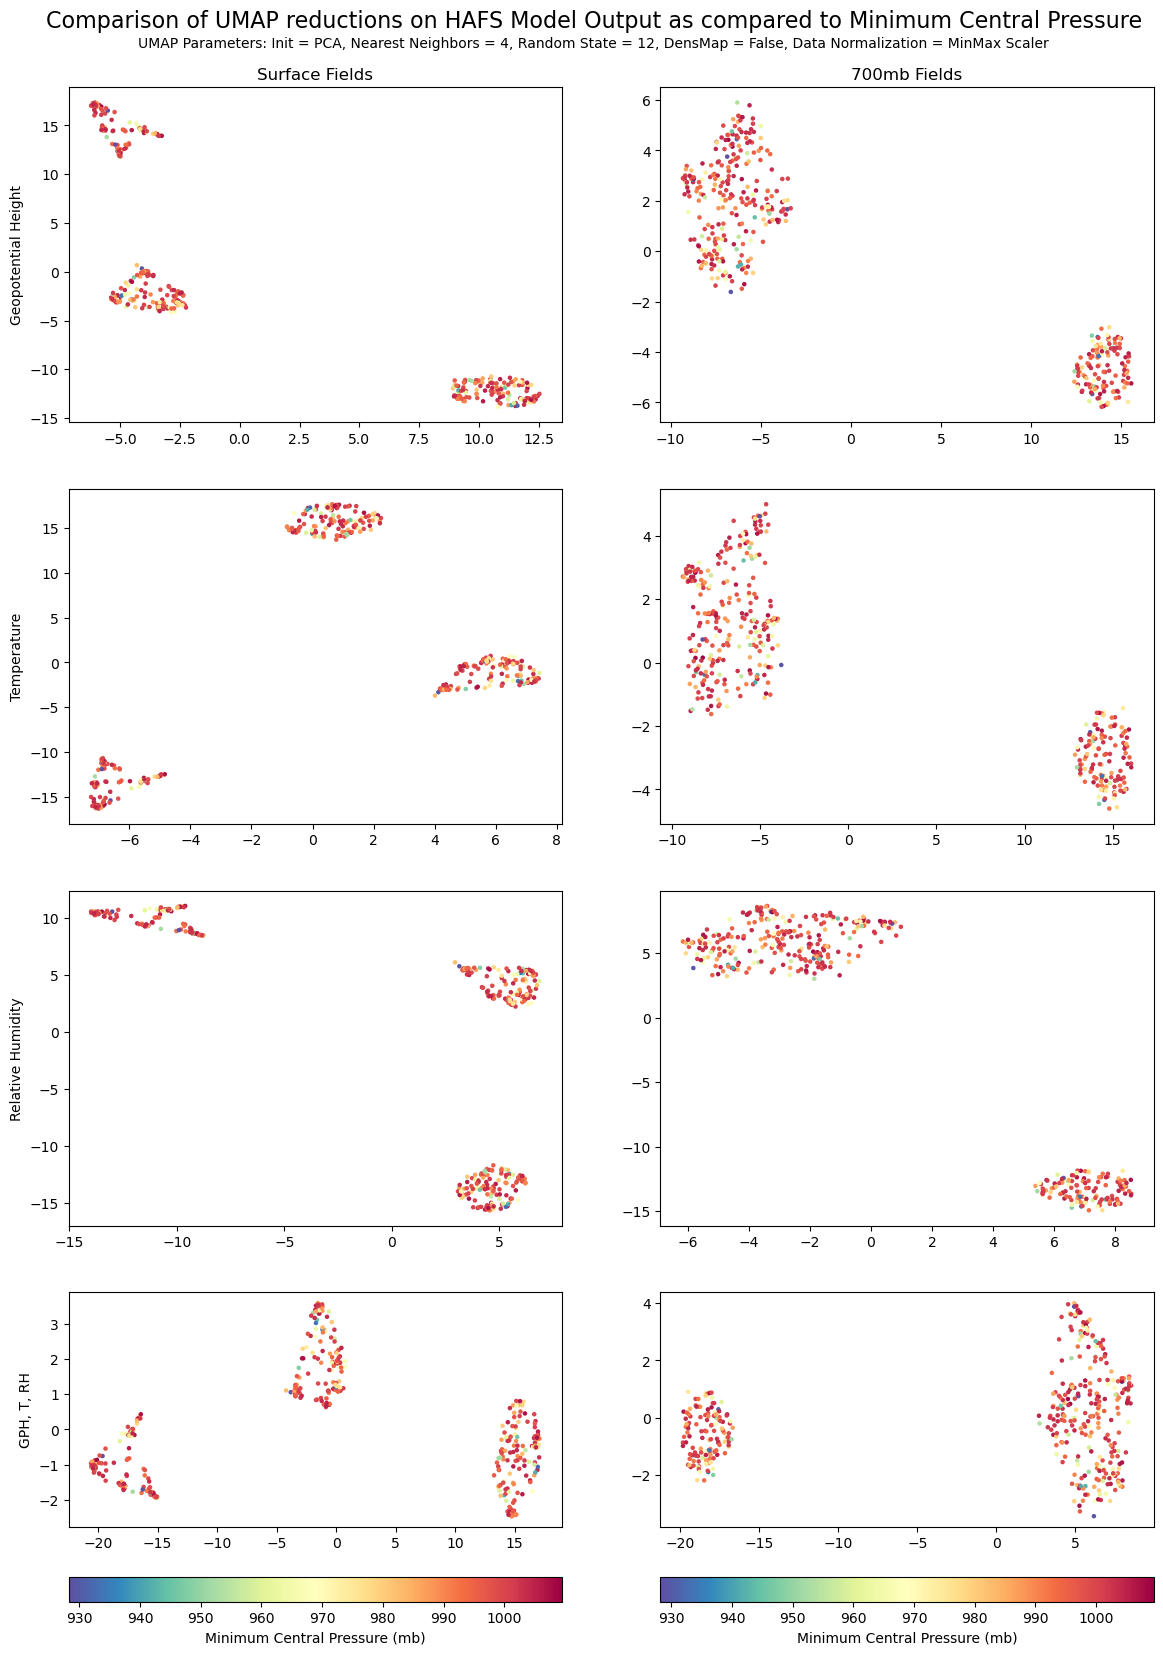

In [52]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (14,20))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface Fields')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,1].set_title('700mb Fields')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)

ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(mslp_im, ax = ax[3,1], location = 'bottom', label = 'Minimum Central Pressure (mb)')

# fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')
fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to Minimum Central Pressure', fontsize=16, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Plotting UMAP Results Compare to Max Winds

Text(0.5, 0.9, 'UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler')

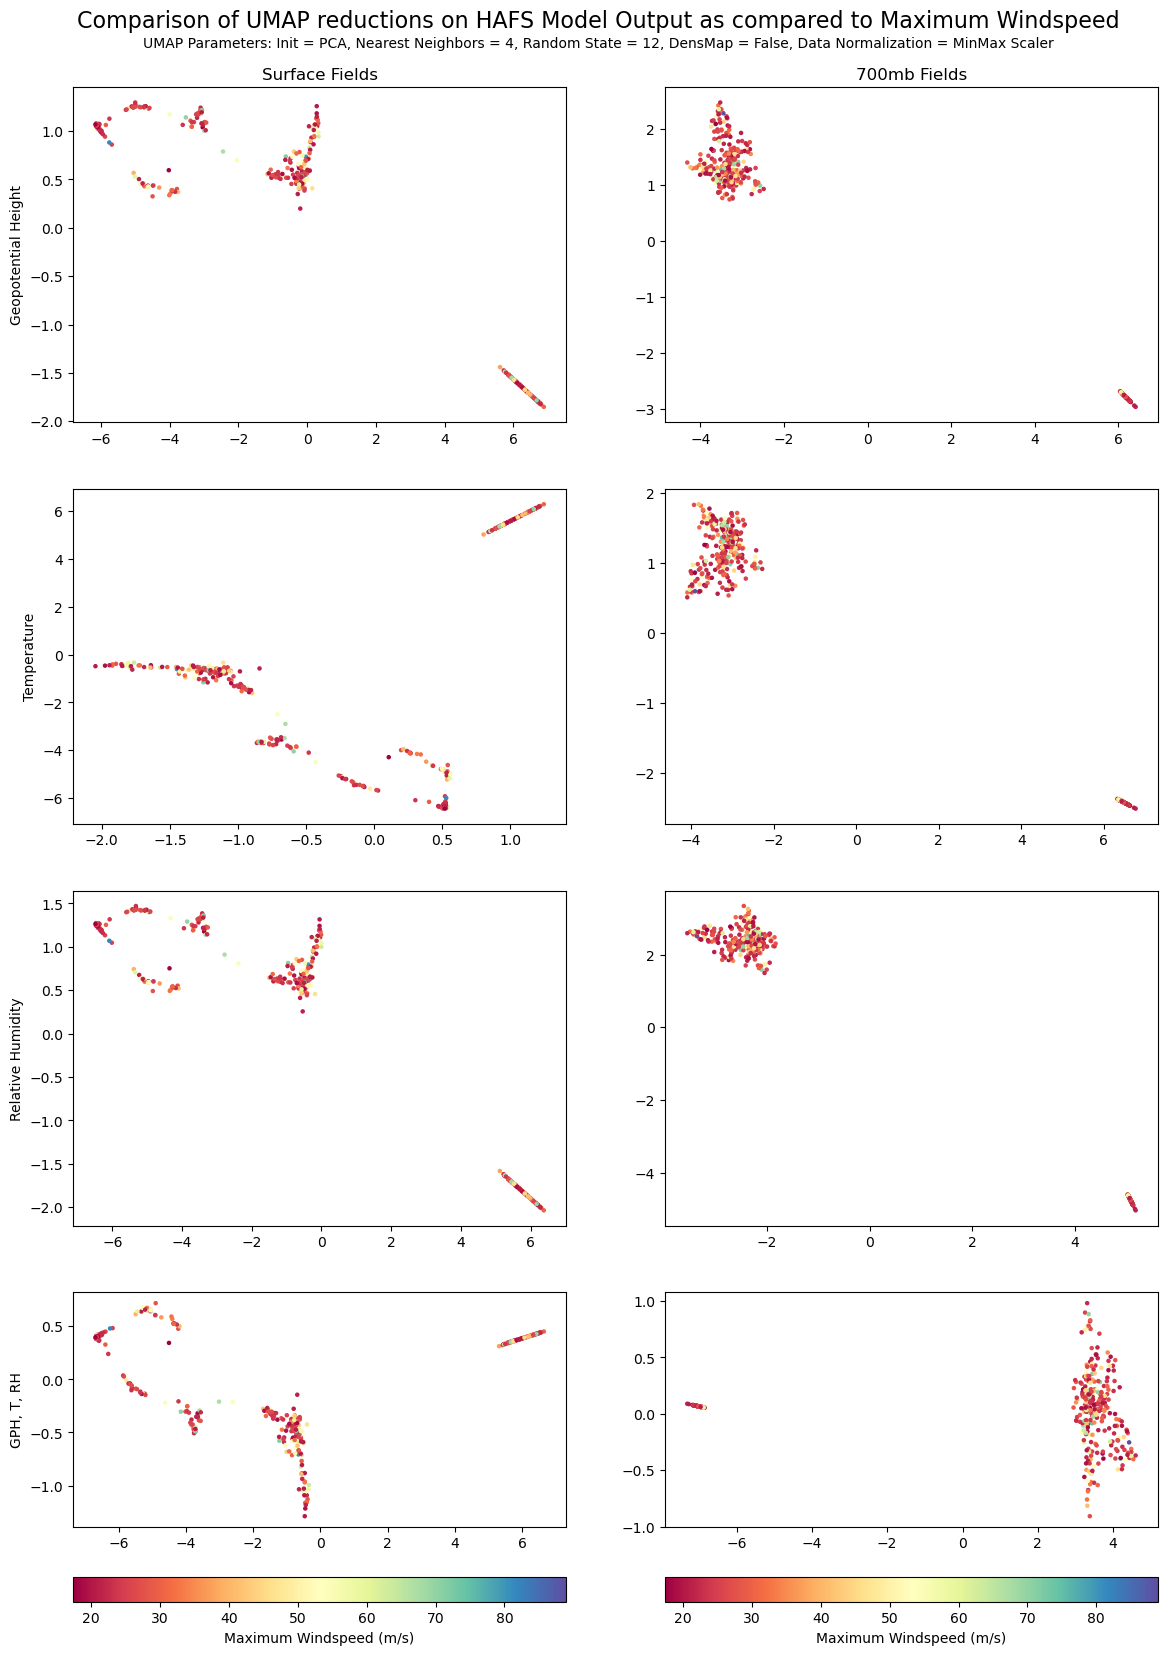

In [48]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (14,20))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface Fields')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = 'Maximum Windspeed (m/s)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('700mb Fields')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(mslp_im, ax = ax[3,1], location = 'bottom', label = 'Maximum Windspeed (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')
fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to Maximum Windspeed', fontsize=16, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Plotting UMAP Results Compare to Pressure Change 24hrs

Text(0.5, 0.9, 'UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler')

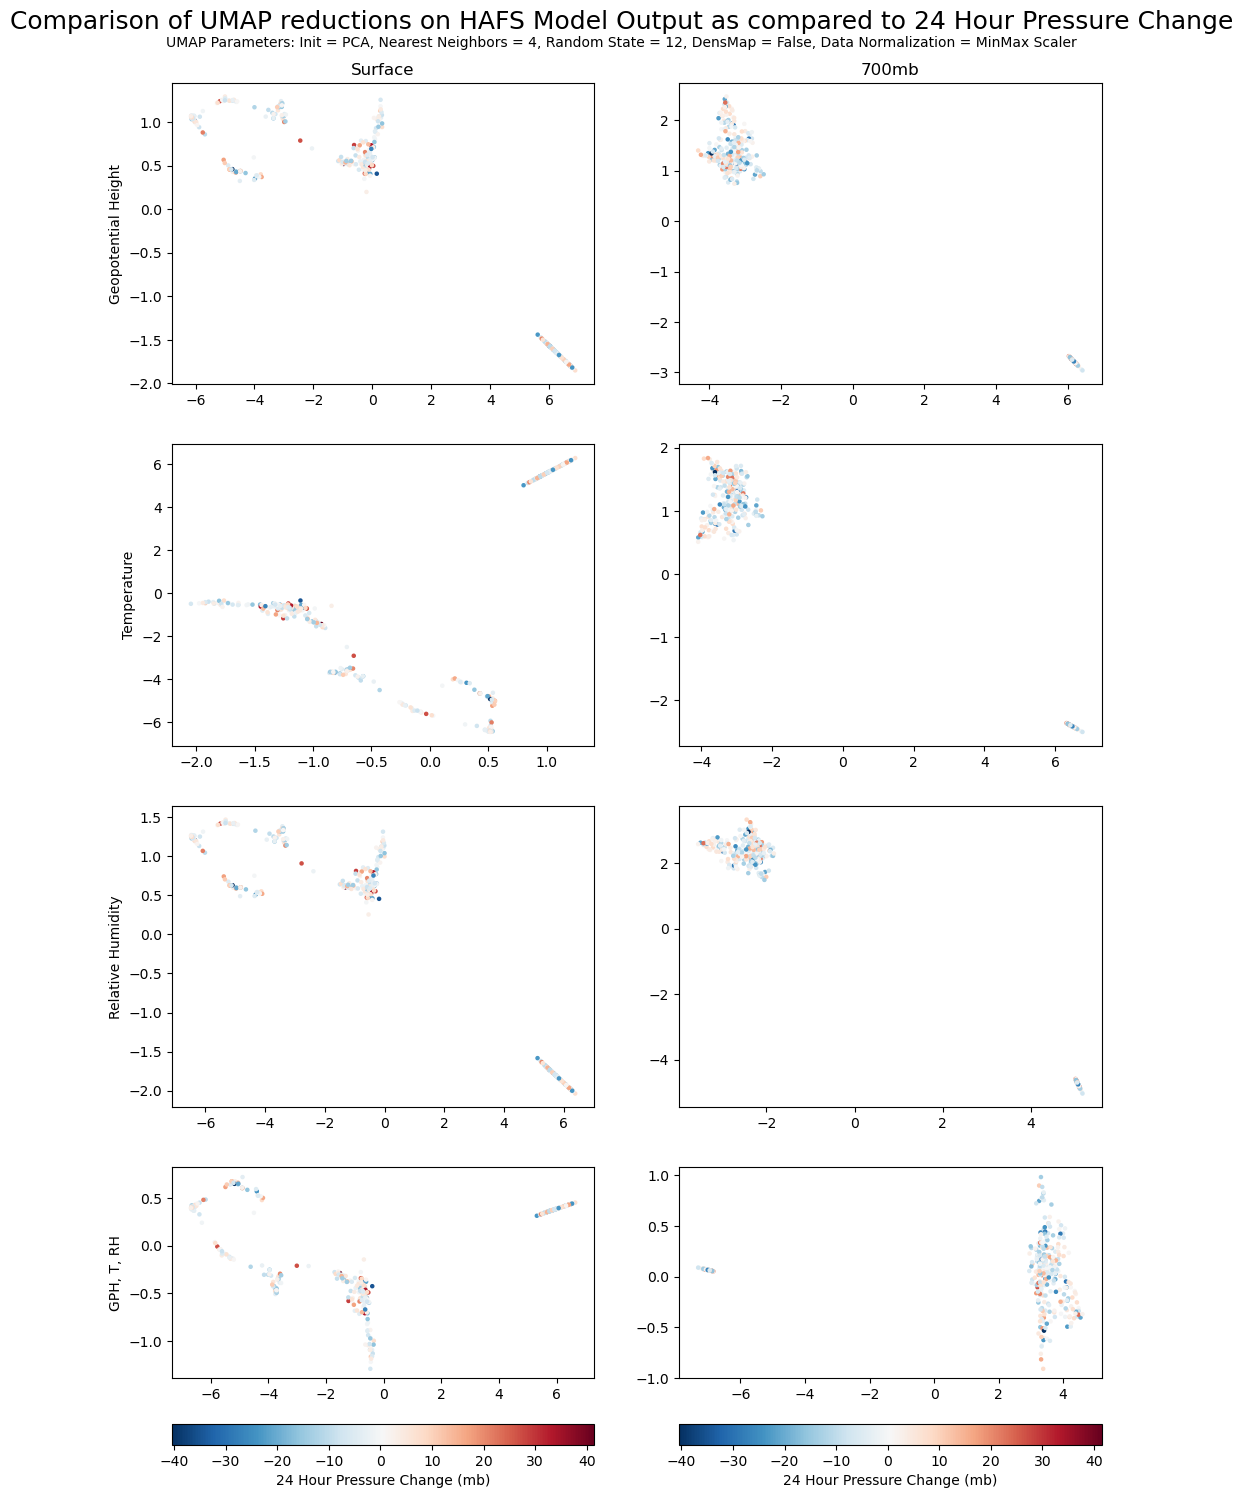

In [49]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (12,18))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = '24 Hour Pressure Change (mb)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[0,1].set_title('700mb')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

max_wind_im = ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[3,1], location = 'bottom', label = '24 Hour Pressure Change (mb)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Pressure Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Text(0.5, 0.9, 'UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler')

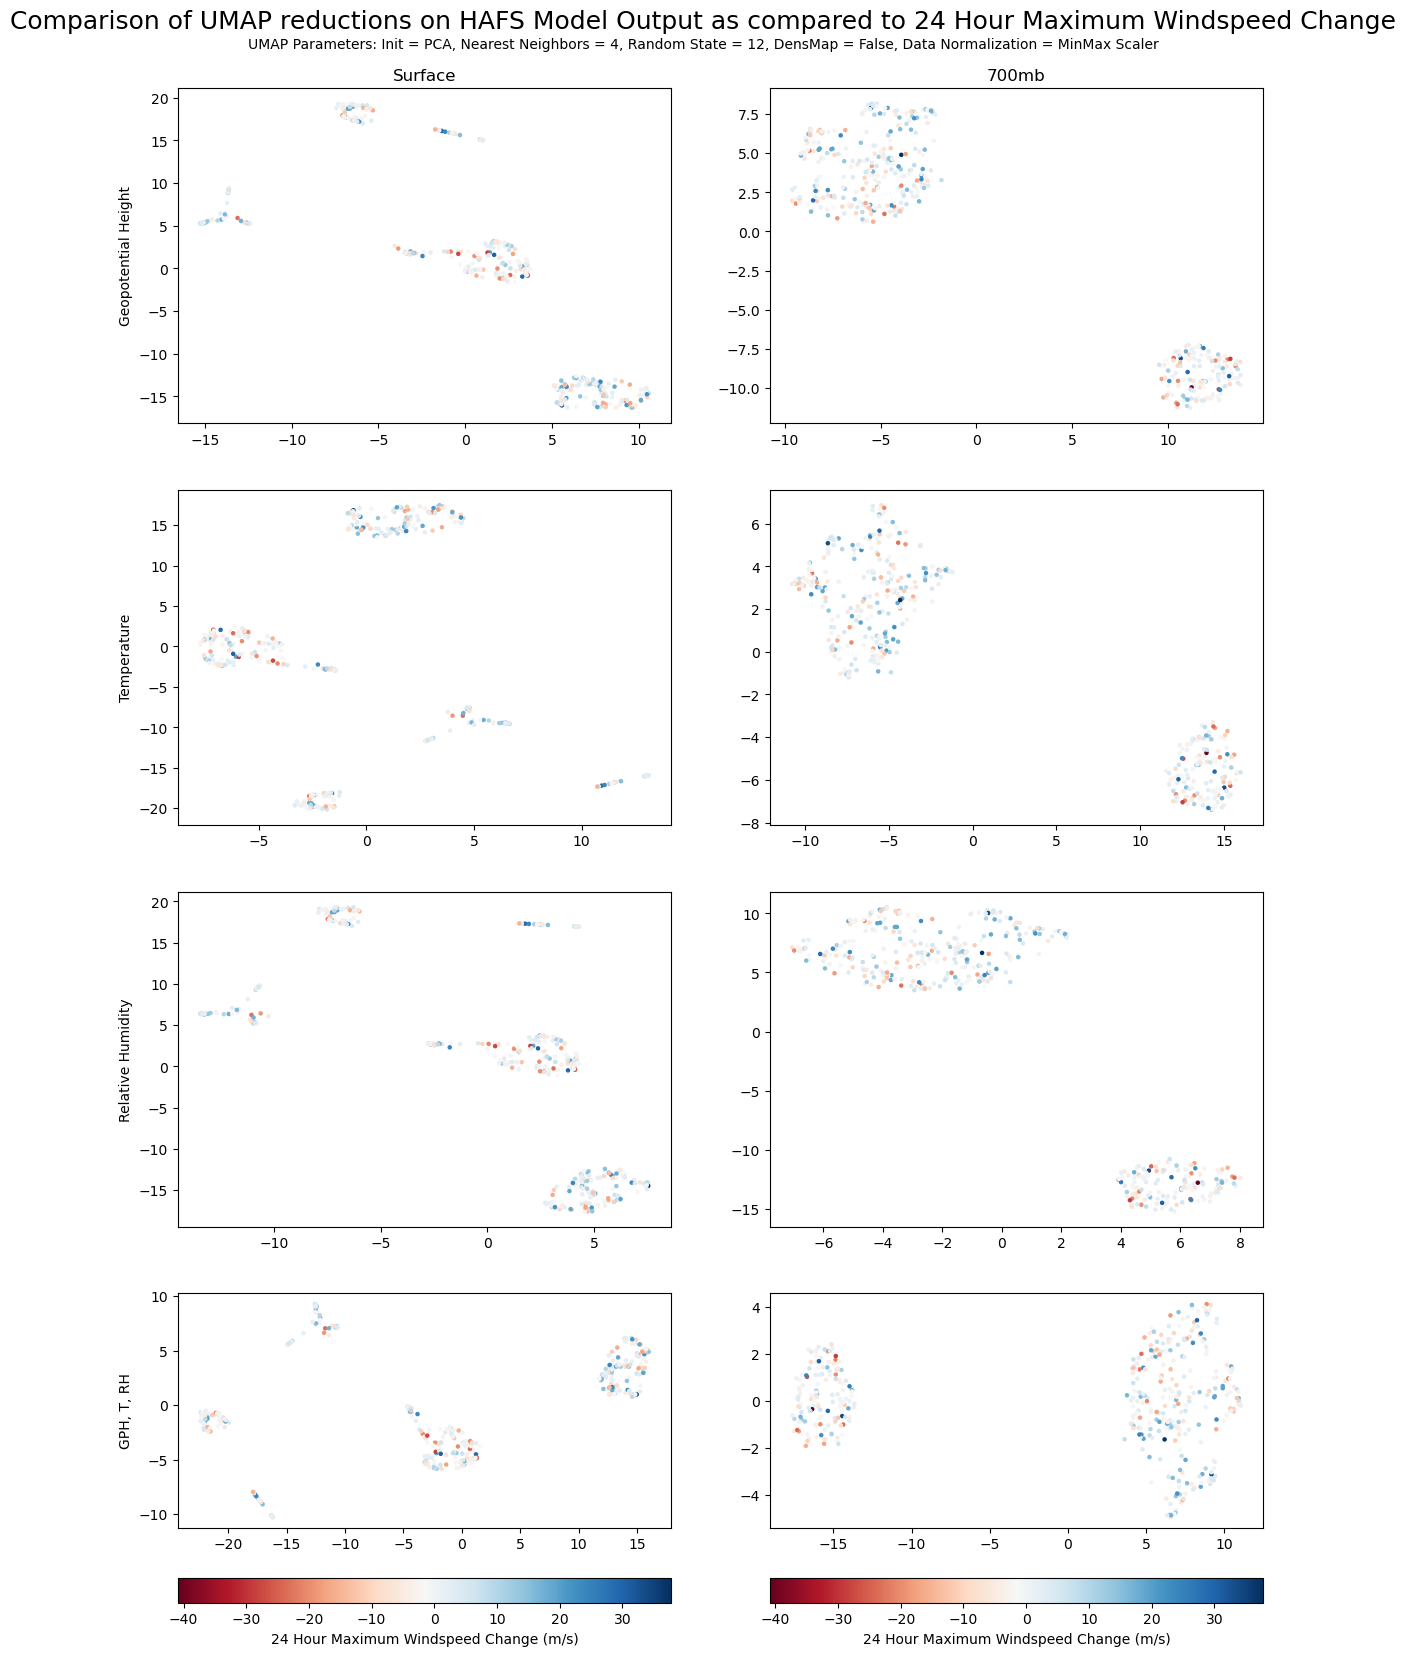

In [26]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (14,20))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,1].set_title('700mb')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

max_wind_im = ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[3,1], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Maximum Windspeed Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Text(0.5, 0.95, 'UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler')

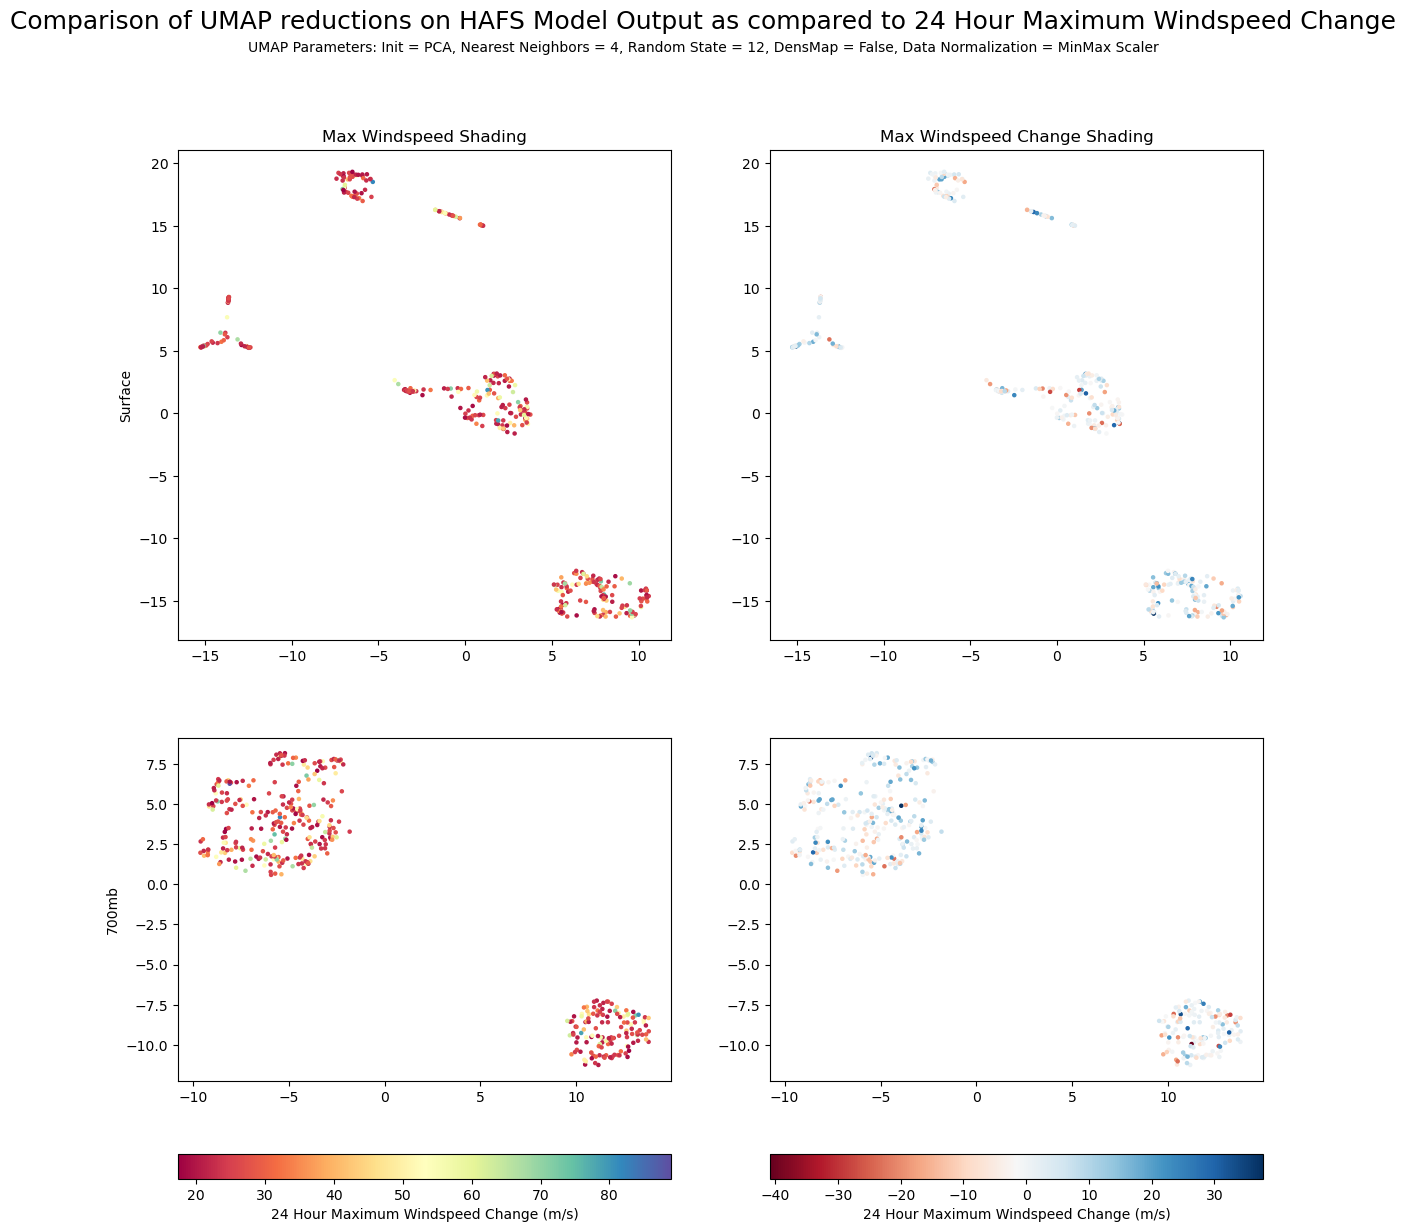

In [27]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (14,14))

sfc_ws_im = ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('Surface')
ax[0,0].set_title('Max Windspeed Shading')

ax[1,0].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('700mb')



# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(sfc_ws_im, ax = ax[1,0], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

ax[0,1].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,1].set_title('Max Windspeed Change Shading')

sfc_ws_change_im = ax[1,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(sfc_ws_change_im, ax = ax[1,1], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.suptitle( 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Maximum Windspeed Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.95, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Computing Composites for two strengthening and two weakening clusters in the 700mb GPH

In [10]:

filter_y = (embedding_GH700_n5[:,1] > 3) & (embedding_GH700_n5[:,1] < 4)
filter_x = (embedding_GH700_n5[:,0] > -5) & (embedding_GH700_n5[:,0] < -3)
cluster1_filter = filter_x * filter_y

filter_y = (embedding_GH700_n5[:,1] > 2) & (embedding_GH700_n5[:,1] < 4)
filter_x = (embedding_GH700_n5[:,0] > 7) & (embedding_GH700_n5[:,0] < 10)
cluster2_filter = filter_x * filter_y

filter_y = (embedding_GH700_n5[:,1] > 1) & (embedding_GH700_n5[:,1] < 2)
filter_x = (embedding_GH700_n5[:,0] > -1) & (embedding_GH700_n5[:,0] < 0.2)
cluster3_filter = filter_x * filter_y

filter_y = (embedding_GH700_n5[:,1] > 5.2) & (embedding_GH700_n5[:,1] < 6.2)
filter_x = (embedding_GH700_n5[:,0] > 0) & (embedding_GH700_n5[:,0] < 2)
cluster4_filter = filter_x * filter_y

In [ ]:
UMAP_embedding = embedding_GH700_n5
composite_filter = cluster4_filter
cluster_wind_change = wind_change[composite_filter]
plt.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
plt.scatter(UMAP_embedding[composite_filter,0], UMAP_embedding[composite_filter,1], 
            cmap = 'Spectral', c = cluster_wind_change, s = 5,
            vmin = windspeed_min,
            vmax = windspeed_max)

In [11]:
cluster1_wind_change = wind_change[cluster1_filter]
avg_cluster1_wind_change = np.nanmean(cluster1_wind_change)
cluster1_winds = max_winds[cluster1_filter]
avg_cluster1_wind = np.nanmean(cluster1_winds)

cluster2_wind_change = wind_change[cluster2_filter]
avg_cluster2_wind_change = np.nanmean(cluster2_wind_change)
cluster2_winds = max_winds[cluster2_filter]
avg_cluster2_wind = np.nanmean(cluster2_winds)

cluster3_wind_change = wind_change[cluster3_filter]
avg_cluster3_wind_change = np.nanmean(cluster3_wind_change)
cluster3_winds = max_winds[cluster3_filter]
avg_cluster3_wind = np.nanmean(cluster3_winds)

cluster4_wind_change = wind_change[cluster4_filter]
avg_cluster4_wind_change = np.nanmean(cluster4_wind_change)
cluster4_winds = max_winds[cluster4_filter]
avg_cluster4_wind = np.nanmean(cluster4_winds)

wind_change_min = np.min(wind_change)
wind_change_max = np.max(wind_change)
windspeed_min = np.min(max_winds)
windspeed_max = np.max(max_winds)

In [ ]:
def field_anomaly_calc(field_array, filter):
    
    n_samples = 1000

    cluster_size = np.sum(filter)
    bootstrap_anomalies = []

    mean_field = np.mean(field_array, axis = 0)
    field_anomalies = field_array - mean_field
    cluster_field_anomalies = field_anomalies[filter, :, :]


    # for n in range(n_samples):
    #     indices = np.random.choice(field_anomalies.shape[0], size = cluster_size, replace = True)
    #     sample_fields = field_anomalies[indices, :, :]
    #     mean_sample = np.mean(sample_fields, axis = 0)
    #     bootstrap_anomalies.append(mean_sample)
    # upper95 = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # lower05 = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])


    # for i in range(field_anomalies.shape[1]):
    #     for j in range(field_anomalies.shape[2]):
    #         upper95[i,j] = np.quantile(bootstrap_anomalies[:][i][j], .95)
    #         lower05[i,j] = np.quantile(bootstrap_anomalies[:][i][j], .05)
    
    cluster_field_mean_anomaly = np.mean(cluster_field_anomalies, axis = 0)
    
    # significantU = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # significantL = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # significantU[cluster_field_mean_anomaly > upper95] = True
    # significantL[cluster_field_mean_anomaly < lower05] = True

    # significant_areas = significantL + significantU
    # significant_areas_coords = np.where(significant_areas == 1)
    # sig_coords_radius = []
    

    return cluster_field_mean_anomaly, np.min(cluster_field_mean_anomaly), np.max(cluster_field_mean_anomaly) #significant_areas_coords,
    
    

In [ ]:
def get_CI(field_anomalies, filter):
    n_samples = 1000

    cluster_size = np.sum(filter)
    bootstrap_anomalies = []
    for n in range(n_samples):
            indices = np.random.choice(field_anomalies.shape[0], size = cluster_size, replace = True)
            sample_fields = field_anomalies[indices, :, :]
            mean_sample = np.mean(sample_fields, axis = 0)
            bootstrap_anomalies.append(mean_sample)
            
 
    
    upper95 = np.quantile(bootstrap_anomalies, .975, axis = 0)
    lower05 = np.quantile(bootstrap_anomalies, .025, axis = 0)
        

    return lower05, upper95  
    # significantU = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # significantL = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # significantU[cluster_field_mean_anomaly > upper95] = True
    # significantL[cluster_field_mean_anomaly < lower05] = True

    # significant_areas = significantL + significantU
    # significant_areas_coords = np.where(significant_areas == 1)
    # sig_coords_radius = []

In [14]:
def robust_mean(x, axis):
    return np.mean(x, axis = axis)

level = 1
composite_filter = cluster4_filter

angle = ds_cleaned.angle.values
radius = ds_cleaned.radius.values

ds_gph = ds_cleaned['gh'].isel(levels = level).values
ds_t = ds_cleaned['t'].isel(levels = level).values
max_winds = ds_cleaned['max_wind'].values[:,0]
wind_change = ds_cleaned['24HrMaxWinds'].isel(levels = 0).values - max_winds

cluster_wind_change = wind_change[composite_filter]
avg_cluster_wind_change = np.nanmean(cluster_wind_change)
cluster_winds = max_winds[composite_filter]
avg_cluster_wind = np.nanmean(cluster_winds)

#### GH Composite ####
mean_field_gh = np.mean(ds_gph, axis = 0)
field_anomalies_gh = ds_gph - mean_field_gh
cluster_field_anomalies_gh = field_anomalies_gh[composite_filter, :, :]
cluster_field_mean_gh = np.mean(cluster_field_anomalies_gh, axis = 0)

CI_gh = bootstrap((field_anomalies_gh,), 
                statistic = robust_mean, 
                vectorized = True,
                axis = 0,
                n_resamples = 1000,  
                batch = 20)

sig_upper_gh = np.where(CI_gh.confidence_interval.high < cluster_field_mean_gh)
sig_upper_x_gh = sig_upper_gh[0]/2
sig_upper_y_gh = sig_upper_gh[1]/2

sig_lower_gh = np.where(CI_gh.confidence_interval.low > cluster_field_mean_gh)
sig_lower_x_gh = sig_lower_gh[0]/2
sig_lower_y_gh = sig_lower_gh[1]/2

#### T Composite #####
mean_field_t = np.mean(ds_t, axis = 0)
field_anomalies_t = ds_t - mean_field_t
cluster_field_anomalies_t = field_anomalies_t[composite_filter, :, :]
cluster_field_mean_t = np.mean(cluster_field_anomalies_t, axis = 0)

CI_t = bootstrap((field_anomalies_t,), 
                statistic = robust_mean, 
                vectorized = True,
                axis = 0,
                n_resamples = 1000,  
                batch = 20)

sig_upper_t = np.where(CI_t.confidence_interval.high < cluster_field_mean_t)
sig_upper_x_t = sig_upper_t[0]/2
sig_upper_y_t = sig_upper_t[1]/2

sig_lower_t = np.where(CI_t.confidence_interval.low > cluster_field_mean_t)
sig_lower_x_t = sig_lower_t[0]/2
sig_lower_y_t = sig_lower_t[1]/2

# fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 12), subplot_kw= {'projection':'polar'})
# Theta, R = np.meshgrid(angle, radius)
# height_im = ax[0].pcolormesh(angle, radius, cluster_field_anomalies_gh, cmap = 'RdBu', shading = 'nearest')
# ax[0].scatter(sig_upper_x_gh, sig_upper_y_gh, alpha = 0.01, color = 'black', marker = 'x', s = 1)
# ax[0].grid(False)
# ax[0].set_theta_direction(-1)
# ax[0].set_theta_offset(np.pi/2)
    # ax[0].text(5.48,450, f'24hr Mean Max Wind Change: {avg_cluster_wind_change:.2f} m/s')
    # ax[0].set_title('Geopotential Height')
    # ax00_inset = ax[0].inset_axes([.8, .65, .5, .4])
    # ax00_inset.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
    # ax00_inset.scatter(UMAP_embedding[filter,0], UMAP_embedding[filter,1], 
    #                c = cluster_winds, cmap = 'Spectral', s = 5,
    #                vmin = windspeed_min,
    #                vmax = windspeed_max)
    # fig.colorbar(height_im,cax = ax[0], location = 'bottom')

In [ ]:
def robust_mean(x, axis):
    return np.mean(x, axis = axis)

res = bootstrap((field_anomalies_gh,), 
                statistic = robust_mean, 
                vectorized = True,
                axis = 0,
                n_resamples = 1000,  
                batch = 10)

In [ ]:
def robust_mean(x, axis):
    return np.mean(x, axis = axis)

res = bootstrap((field_anomalies_t,), 
                statistic = robust_mean, 
                vectorized = True,
                axis = 0,
                n_resamples = 1000,  
                batch = 10)

In [ ]:
sig_upper_gh = np.where(res.confidence_interval.high < cluster_field_mean_gh)
sig_upper_x_gh = sig_upper_gh[0]/2
sig_upper_y_gh = sig_upper_gh[1]/2

sig_lower_gh = np.where(res.confidence_interval.low > cluster_field_mean_gh)
sig_lower_x_gh = sig_lower_gh[0]/2
sig_lower_y_gh = sig_lower_gh[1]/2

sig_upper_t = np.where(res.confidence_interval.high < cluster_field_mean_t)
sig_upper_x_t = sig_upper_t[0]/2
sig_upper_y_t = sig_upper_t[1]/2

sig_lower_t = np.where(res.confidence_interval.low > cluster_field_mean_t)
sig_lower_x_t = sig_lower_t[0]/2
sig_lower_y_t = sig_lower_t[1]/2

Text(0.5, 0.98, 'Cluster Average Windspeed is 23.93 m/s \nCluster Average 24hr Storm Intensity Change is 12.67 m/s')

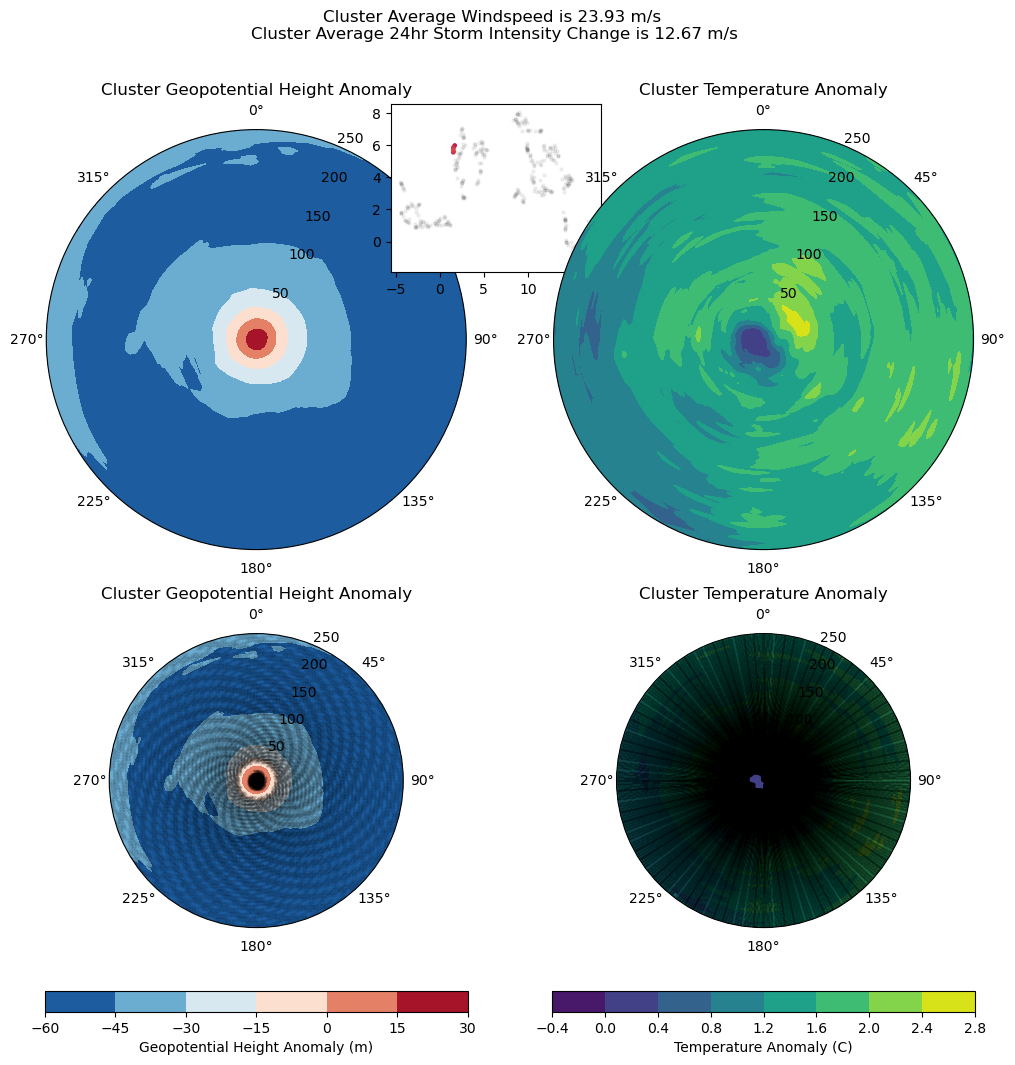

In [18]:
title = 'Test'
UMAP_embedding = embedding_GH700_n5

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 12), subplot_kw= {'projection':'polar'})
Theta, R = np.meshgrid(angle, radius)
height_im = ax[0,0].contourf(angle, radius, cluster_field_mean_gh.T, cmap = 'RdBu_r')
# ax[0,0].scatter(sig_upper_x_gh[::50], sig_upper_y_gh[::50], alpha = 0.1, color = 'black', marker = 'x', s = 10)
# ax[0,0].scatter(sig_lower_x_gh[::50], sig_lower_y_gh[::50], alpha = 0.1, color = 'black', marker = 'x', s = 10)
ax[0,0].grid(False)
ax[0,0].set_theta_direction(-1)
ax[0,0].set_theta_offset(np.pi/2)
ax[0,0].set_title('Cluster Geopotential Height Anomaly')
fig.colorbar(height_im, ax = ax[1,0], location = 'bottom', label = 'Geopotential Height Anomaly (m)')

temp_im = ax[0,1].contourf(angle, radius, cluster_field_mean_t.T, cmap = 'viridis')
# ax[0,1].scatter(sig_upper_x_t[::60], sig_upper_y_t[::60], alpha = 0.15, color = 'black', marker = '*', s = 5)
# ax[0,1].scatter(sig_lower_x_t[::60], sig_lower_y_t[::60], alpha = 0.15, color = 'black', marker = '*', s = 5)
ax[0,1].grid(False)
ax[0,1].set_theta_direction(-1)
ax[0,1].set_theta_offset(np.pi/2)
ax[0,1].set_title('Cluster Temperature Anomaly')
fig.colorbar(temp_im, ax = ax[1,1], location = 'bottom', label = 'Temperature Anomaly (C)')

ax00_inset = ax[0,0].inset_axes([.82, .66, .5, .4])
ax00_inset.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
ax00_inset.scatter(UMAP_embedding[composite_filter,0], UMAP_embedding[composite_filter,1], 
                   c = cluster_winds, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)


height_im = ax[1,0].contourf(angle, radius, cluster_field_mean_gh.T, cmap = 'RdBu_r')
ax[1,0].scatter(sig_upper_x_gh[::40], sig_upper_y_gh[::40], alpha = 0.1, color = 'black', marker = 'x', s = 10)
ax[1,0].scatter(sig_lower_x_gh[::40], sig_lower_y_gh[::40], alpha = 0.1, color = 'black', marker = 'x', s = 10)
ax[1,0].grid(False)
ax[1,0].set_theta_direction(-1)
ax[1,0].set_theta_offset(np.pi/2)
ax[1,0].set_title('Cluster Geopotential Height Anomaly')
# fig.colorbar(height_im, ax = ax[1,0], location = 'bottom', label = 'Geopotential Height Anomaly (m)')

temp_im = ax[1,1].contourf(angle, radius, cluster_field_mean_t.T, cmap = 'viridis')
ax[1,1].scatter(sig_upper_x_t, sig_upper_y_t, alpha = 0.05, color = 'black', marker = '*', s = 1)
ax[1,1].scatter(sig_lower_x_t, sig_lower_y_t, alpha = 0.05, color = 'black', marker = '*', s = 1)
ax[1,1].grid(False)
ax[1,1].set_theta_direction(-1)
ax[1,1].set_theta_offset(np.pi/2)
ax[1,1].set_title('Cluster Temperature Anomaly')
# fig.colorbar(temp_im, ax = ax[1,1], location = 'bottom', label = 'Temperature Anomaly (C)')

fig.suptitle(f'Cluster Average Windspeed is {avg_cluster_wind:.2f} m/s \nCluster Average 24hr Storm Intensity Change is {avg_cluster_wind_change:.2f} m/s')

In [ ]:
def composite_plot(ds, filter,UMAP_embedding,title, level = 0,):

    angle = ds.angle.values
    radius = ds.radius.values

    ds_gph = ds['gh'].isel(levels = level).values
    ds_t = ds['t'].isel(levels = level).values
    max_winds = ds_cleaned['max_wind'].values[:,0]
    wind_change = ds_cleaned['24HrMaxWinds'].isel(levels = 0).values - max_winds

    windspeed_max = np.max(max_winds)
    windspeed_min = np.min(max_winds)

    cluster_wind_change = wind_change[filter]
    avg_cluster_wind_change = np.nanmean(cluster_wind_change)
    cluster_winds = max_winds[filter]
    
    print('Calculating Height Anomalies')
    height_anomaly_field, height_min, height_max = field_anomaly_calc(ds_gph, filter)
    # print('Calculating Temp Anomalies')
    # temp_anomaly_field, temp_min, temp_max = field_anomaly_calc(ds_t, filter)

    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 12), subplot_kw= {'projection':'polar'})
    Theta, R = np.meshgrid(angle, radius)

    height_im = ax[0].pcolormesh(angle, radius, height_anomaly_field.T, cmap = 'RdBu', shading = 'nearest')
    # ax[0].scatter(height_sig[0]/2, height_sig[1]/2, alpha = 0.01, color = 'black', marker = 'x', s = 1)
    ax[0].grid(False)
    ax[0].set_theta_direction(-1)
    ax[0].set_theta_offset(np.pi/2)
    ax[0].text(5.48,450, f'24hr Mean Max Wind Change: {avg_cluster_wind_change:.2f} m/s')
    ax[0].set_title('Geopotential Height')
    ax00_inset = ax[0].inset_axes([.8, .65, .5, .4])
    ax00_inset.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
    ax00_inset.scatter(UMAP_embedding[filter,0], UMAP_embedding[filter,1], 
                   c = cluster_winds, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)
    fig.colorbar(height_im,cax = ax[0], location = 'bottom')

    # temp_im = ax[1].pcolormesh(angle, radius, temp_anomaly_field.T, cmap = 'RdBu', shading = 'nearest')
    # # ax[1].scatter(temp_sig[0]/2, temp_sig[1]/2, alpha = 0.01, color = 'black', marker = 'x', s = 1)

    # ax[1].grid(False)
    # ax[1].set_theta_direction(-1)
    # ax[1].set_theta_offset(np.pi/2)
    # ax[1].text(5.48,450, f'24hr Mean Max Wind Change: {avg_cluster_wind_change:.2f} m/s')
    # ax[1].set_title('Geopotential Height')
    
    # fig.colorbar(temp_im,cax = ax[1], location = 'bottom')
    fig.suptitle(title)



In [ ]:
title = 'UMAP Cluster Composites for a Strengthening Cluster at 700mb'
composite_plot(ds_cleaned, strengthening_filter_700mbgph,embedding_GH700_n5, title = title, level = 1 )

In [ ]:
angle = ds_cleaned.angle.values
radius = ds_cleaned.radius.values
ds_700gph = ds_cleaned['gh'].isel(levels = 1).values
ds_700t = ds_cleaned['t'].isel(levels = 1).values
ds_SFCgph = ds_cleaned['gh'].isel(levels = 0).values
ds_SFCt = ds_cleaned['t'].isel(levels = 0).values
mean_height_700 = np.mean(ds_700gph, axis=0)
mean_temp_700 = np.mean(ds_700t, axis = 0)
mean_height_sfc = np.mean(ds_SFCgph, axis=0)
mean_temp_sfc = np.mean(ds_SFCt, axis = 0)

st_gph_anomaly_700, st_gph_sig_700, st_gph_min_700, st_gph_max_700 = field_anomaly_calc(ds_700gph, strengthening_filter_700mbgph)
wk_gph_anomaly_700, wk_gph_sig_700, wk_gph_min_700,wk_gph_max_700 = field_anomaly_calc(ds_700gph, weakening_filter_700mbgph)
st_t_anomaly_700, st_t_sig_700, st_t_min_700, st_t_max_700 = field_anomaly_calc(ds_700t, strengthening_filter_700mbgph)
wk_t_anomaly_700, wk_t_sig_700, wk_t_min_700,wk_t_max_700 = field_anomaly_calc(ds_700t, weakening_filter_700mbgph)


# strengthening1_mean = np.mean(ds_700t[strengthening1_filter_700mbgph,:,:],axis = 0)
# strengthening1_anomaly = strengthening1_mean - mean_temp_700

# strengthening2_mean = np.mean(ds_700t[strengthening2_filter_700mbgph,:,:],axis = 0)
# strengthening2_anomaly = strengthening2_mean - mean_temp_700

# weakening1_mean = np.mean(ds_700t[weakening1_filter_700mbgph,:,:],axis = 0)
# weakening1_anomaly = weakening1_mean - mean_temp_700

# weakening2_mean = np.mean(ds_700t[weakening2_filter_700mbgph,:,:],axis = 0)
# weakening2_anomaly = weakening2_mean - mean_temp_700

# sfc_min_gph = np.min([st_min_sfc, wk_min_sfc])
# sfc_max_gph = np.max([st_max_sfc, wk_max_sfc])
# st_min = np.min([st1_min, st2_min])
# st_max = np.max([st1_max, wk2_max])
fig = plt.figure(figsize=(12, 12))

gs = GridSpec(3, 2, height_ratios=[1, 1, 0.05], wspace=0.3)

ax00 = fig.add_subplot(gs[0,0],projection = 'polar')
ax01 = fig.add_subplot(gs[0,1],projection = 'polar')
ax10 = fig.add_subplot(gs[1,0],projection = 'polar')
ax11 = fig.add_subplot(gs[1,1],projection = 'polar')

Theta, R = np.meshgrid(angle, radius)

st_gph_700_im = ax00.pcolormesh(angle, radius, st_gph_anomaly_700.T, vmin = st_gph_min_700, vmax = st_gph_max_700, cmap = 'RdBu', shading = 'nearest')
# ax00.scatter(st_gph_sig_700[0]/2, st_gph_sig_700[1]/2, alpha = 0.01, color = 'black', marker = 'x', s = 1)
ax00.grid(False)
ax00.set_theta_direction(-1)
ax00.set_theta_offset(np.pi/2)
ax00.text(5.48,450, f'24hr Mean Max Wind Change: {avg_strengthening_wind_change_700:.2f} m/s')
ax00.set_title('Geopotential Height')
ax00_inset = ax00.inset_axes([1.2, .8, .5, .4])
ax00_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax00_inset.scatter(embedding_GH700_n5[strengthening_filter_700mbgph,0], embedding_GH700_n5[strengthening_filter_700mbgph,1], 
                   c = strengthening_winds_700, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)
fig.colorbar(st_gph_700_im, location = 'bottom')

wk_gph_700_im = ax10.pcolormesh(angle, radius, wk_gph_anomaly_700.T, vmin = wk_gph_min_700, vmax = wk_gph_max_700, cmap = 'RdBu')
ax10.grid(False)
ax10.set_theta_direction(-1)
ax10.set_theta_offset(np.pi/2)
ax10.text(5.38,480, f'24hr Mean Max Wind Change: {avg_weakening_wind_change_700:.2f} m/s')
ax10_inset = ax10.inset_axes([1.2, .8, .5, .4])
ax10_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax10_inset.scatter(embedding_GH700_n5[weakening_filter_700mbgph,0], embedding_GH700_n5[weakening_filter_700mbgph,1], 
                   c = weakening_winds_700, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)
fig.colorbar(wk_gph_700_im, location = 'bottom')

st_t_700_im = ax01.pcolormesh(angle, radius,st_t_anomaly_700.T, vmin = st_t_min_700, vmax = st_t_max_700, cmap = 'RdBu')
# ax01.scatter(st_t_sig_700[0]/2, st_t_sig_700[1]/2, alpha = 0.01, color = 'black', marker = 'x', s = 1)
ax01.grid(False)
ax01.set_theta_direction(-1)
ax01.set_theta_offset(np.pi/2)
ax01.text(5.30,480, f'24hr Mean Max Wind Change: {avg_strengthening_wind_change_700:.2f} m/s')
ax01_inset = ax10.inset_axes([.7, .8, .5, .4])
ax01_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax01_inset.scatter(embedding_GH700_n5[strengthening_filter_700mbgph,0], embedding_GH700_n5[strengthening_filter_700mbgph,1], 
                   c = strengthening_winds_700, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)
ax01.set_title('Temperature (C)')
fig.colorbar(st_t_700_im, location = 'bottom')

wk_t_700_im = ax11.pcolormesh(angle, radius,wk_t_anomaly_700.T, vmin = wk_t_min_700, vmax = wk_t_max_700, cmap = 'RdBu')
ax11.grid(False)
ax11.set_theta_direction(-1)
ax11.set_theta_offset(np.pi/2)
ax11.text(5.30,480, f'24hr Mean Max Wind Change: {avg_weakening_wind_change_700:.2f} m/s')
ax11_inset = ax10.inset_axes([.7, .8, .5, .4])
ax11_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax11_inset.scatter(embedding_GH700_n5[weakening_filter_700mbgph,0], embedding_GH700_n5[weakening_filter_700mbgph,1], 
                   c = weakening_winds_700, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)
fig.colorbar(wk_t_700_im, location = 'bottom')

# st1 = ax01.pcolormesh(R, Theta, st1_field_anomaly, vmin = st_min, vmax = st_max, cmap = 'RdBu')
# ax01.grid(False)
# ax01.set_theta_direction(-1)
# ax01.set_theta_offset(np.pi/2)
# ax01.text(5.5,585, f'24hr Mean Max Wind Change: {avg_strengthening1_wind_change:.2f} m/s')
# ax01.set_title('Strengthening Clusters')
# ax01_inset = ax01.inset_axes([.7, .8, .5, .4])
# ax01_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
# ax01_inset.scatter(embedding_GH700_n5[strengthening1_filter_700mbgph,0], embedding_GH700_n5[strengthening1_filter_700mbgph,1], 
#                    c = strengthening1_winds, cmap = 'Spectral', s = 5,
#                    vmin = windspeed_min,
#                    vmax = windspeed_max)

# st2 = ax11.pcolormesh(R, Theta, st2_field_anomaly, vmin = st_min, vmax = st_max, cmap = 'RdBu')
# ax11.grid(False)
# ax11.set_theta_direction(-1)
# ax11.set_theta_offset(np.pi/2)
# ax11.text(5.4,570, f'24hr Mean Max Wind Change: {avg_strengthening2_wind_change:.2f} m/s')
# ax11_inset = ax11.inset_axes([.7, .8, .5, .4])
# ax11_inset.scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
# ax11_inset.scatter(embedding_GH700_n5[strengthening2_filter_700mbgph,0], embedding_GH700_n5[strengthening2_filter_700mbgph,1], 
#                    c = strengthening2_winds, cmap = 'Spectral_r', s = 5,
#                    vmin = windspeed_min,
#                    vmax = windspeed_max)
# # cb1_axe = fig.add_axes([.05, 0.05, .4,0.15])

# # weakening_cax = weakening_divider.append_axes('bottom', size = "5%", pad = 0.05)

# fig.colorbar(wk2, cax = cax20, label = '700mb Geopotential Height Anomaly (m)', orientation = 'horizontal')
# fig.colorbar(st2, cax = cax21,  label = '700mb Geopotential Height Anomaly (m)', orientation = 'horizontal')



Computing composites for both clusters the 700mb GPH, T, RH combined cluster

In [ ]:
filter_y = embedding_Full700_n5[:,1] > 5
filter_x = embedding_Full700_n5[:,0] < 0
cluster1_filter_700mbFull = filter_x * filter_y

filter_y = embedding_Full700_n5[:,1] < 6
filter_x = embedding_Full700_n5[:,0] > 10
cluster2_filter_700mbFull = filter_x * filter_y

cluster1_wind_change = wind_change[cluster1_filter_700mbFull]
cluster2_wind_change = wind_change[cluster2_filter_700mbFull]



In [ ]:
angle = ds_cleaned.angle.values
radius = ds_cleaned.radius.values
ds_700gph = ds_cleaned['gh'].isel(levels = 1).values
mean_height_700 = np.mean(ds_700gph, axis=0)
ds_700t = ds_cleaned['t'].isel(levels = 1).values
mean_temp_700 = np.mean(ds_700t, axis=0)
ds_700rh = ds_cleaned['rh'].isel(levels = 1).values
mean_relhum_700 = np.mean(ds_700rh, axis=0)

cluster1_gph_mean = np.mean(ds_700gph[cluster1_filter_700mbFull,:,:],axis = 0)
cluster1_gph_anomaly = cluster1_gph_mean - mean_height_700

cluster1_t_mean = np.mean(ds_700t[cluster1_filter_700mbFull,:,:],axis = 0)
cluster1_t_anomaly = cluster1_t_mean - mean_temp_700

cluster1_rh_mean = np.mean(ds_700rh[cluster1_filter_700mbFull,:,:],axis = 0)
cluster1_rh_anomaly = cluster1_rh_mean - mean_relhum_700

cluster2_gph_mean = np.mean(ds_700gph[cluster2_filter_700mbFull,:,:],axis = 0)
cluster2_gph_anomaly = cluster2_gph_mean - mean_height_700

cluster2_t_mean = np.mean(ds_700t[cluster2_filter_700mbFull,:,:],axis = 0)
cluster2_t_anomaly = cluster2_t_mean - mean_temp_700

cluster2_rh_mean = np.mean(ds_700rh[cluster2_filter_700mbFull,:,:],axis = 0)
cluster2_rh_anomaly = cluster2_rh_mean - mean_relhum_700

gph_min = np.min([cluster2_gph_anomaly, cluster1_gph_anomaly])
gph_max = np.max([cluster2_gph_anomaly, cluster1_gph_anomaly])
t_min = np.min([cluster2_t_anomaly, cluster1_t_anomaly])
t_max = np.max([cluster2_t_anomaly, cluster1_t_anomaly])
rh_min = np.min([cluster2_rh_anomaly, cluster1_rh_anomaly])
rh_max = np.max([cluster2_rh_anomaly, cluster1_rh_anomaly])

fig = plt.figure(figsize=(12, 12))

R, Theta = np.meshgrid(radius, angle)

gs = GridSpec(3, 3, width_ratios=[1, 1, 0.05], wspace=0.5)
ax00 = fig.add_subplot(gs[0,0],projection = 'polar')
ax01 = fig.add_subplot(gs[0,1],projection = 'polar')
ax10 = fig.add_subplot(gs[1,0],projection = 'polar')
ax11 = fig.add_subplot(gs[1,1],projection = 'polar')
ax20 = fig.add_subplot(gs[2,0],projection = 'polar')
ax21 = fig.add_subplot(gs[2,1],projection = 'polar')
cax03 = fig.add_subplot(gs[0,2])
cax13 = fig.add_subplot(gs[1,2])
cax23 = fig.add_subplot(gs[2,2])

clst1_gph_im = ax00.pcolormesh(R, Theta, cluster1_gph_anomaly, vmin = gph_min, vmax = gph_max, cmap = 'RdBu_r')
ax00.grid(False)
ax00.set_theta_direction(-1)
ax00.set_theta_offset(np.pi/2)
ax00.set_ylabel('700mb Geopotential Height', labelpad = 40)
ax00.set_title('Cluster 1')
ax00_inset = ax00.inset_axes([.85, .75, .5, .4])
ax00_inset.scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax00_inset.scatter(embedding_Full700_n5[cluster1_filter_700mbFull,0], embedding_Full700_n5[cluster1_filter_700mbFull,1], 
                   c = cluster1_wind_change, cmap = 'RdBu', s = 5,
                   vmin = wind_change_min,
                   vmax = wind_change_max)

clst2_gph_im = ax01.pcolormesh(R, Theta, cluster2_gph_anomaly, vmin = gph_min, vmax = gph_max, cmap = 'RdBu_r')
ax01.grid(False)
ax01.set_theta_direction(-1)
ax01.set_theta_offset(np.pi/2)
ax01.set_title('Cluster 2')
ax01_inset = ax01.inset_axes([.85, .75, .5, .4])
ax01_inset.scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1],color = 'black', s = 5, alpha = 0.05)
ax01_inset.scatter(embedding_Full700_n5[cluster2_filter_700mbFull,0], embedding_Full700_n5[cluster2_filter_700mbFull,1], 
                   c = cluster2_wind_change, cmap = 'RdBu', s = 5,
                   vmin = wind_change_min,
                   vmax = wind_change_max)

clst1_t_im = ax10.pcolormesh(R, Theta, cluster1_t_anomaly, vmin = t_min, vmax = t_max, cmap = 'RdBu_r')
ax10.grid(False)
ax10.set_theta_direction(-1)
ax10.set_theta_offset(np.pi/2)
ax10.set_ylabel('700mb Temperature', labelpad = 40)

clst2_t_im = ax11.pcolormesh(R, Theta, cluster2_t_anomaly, vmin = t_min, vmax = t_max, cmap = 'RdBu_r')
ax11.grid(False)
ax11.set_theta_direction(-1)
ax11.set_theta_offset(np.pi/2)

clst1_rh_im = ax20.pcolormesh(R, Theta, cluster1_rh_anomaly, vmin = rh_min, vmax = rh_max, cmap = 'RdBu')
ax20.grid(False)
ax20.set_theta_direction(-1)
ax20.set_theta_offset(np.pi/2)
ax20.set_ylabel('700mb Relative Humidity', labelpad = 40)

clst2_rh_im = ax21.pcolormesh(R, Theta, cluster2_rh_anomaly, vmin = rh_min, vmax = rh_max, cmap = 'RdBu')
ax21.grid(False)
ax21.set_theta_direction(-1)
ax21.set_theta_offset(np.pi/2)

fig.colorbar(clst1_gph_im, cax = cax03, label = 'm')
fig.colorbar(clst1_t_im, cax = cax13, label = 'C')
fig.colorbar(clst1_rh_im, cax = cax23, label = '% Relative Humidity')


# gs.tight_layout(fig)
